# Первичный анализ данных: локальный рецидив рака ротоглотки

Исходная таблица — `w3/dataset.csv` (результат недели 3), файл не изменяется.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw = pd.read_csv("../w3/dataset.csv")
raw.shape

(298, 235)

In [3]:
raw["Patient_ID"].is_unique

True

In [4]:
gtvp = [col for col in raw.columns if col.startswith("GTVp_")]
gtvn = [col for col in raw.columns if col.startswith("GTVn_") and col != "GTVn_n_nodes"]
radiomic = gtvp + gtvn
clinical = [col for col in raw.columns if col not in radiomic]

len(clinical), len(gtvp), len(gtvn)

(21, 107, 107)

In [5]:
raw[clinical].head()

,Patient_ID,Fold,Local_tumor_recurrence,Gender,Age_at_diagnosis,Race,Tumor_side,Tumor_subsite,T_category,N_category,...,Pathological_grade,Smoking_status_at_diagnosis,Smoking_Pack-Years,Radiation_treatment_course_duration,Total_prescribed_Radiation_treatment_dose,#_Radiation_treatment_fractions,Induction_Chemotherapy,Concurrent_chemotherapy,KM_Overall_survival_censor,GTVn_n_nodes
0,1,Training,0.0,Male,58,White,L,Tonsil,2,0,...,III,Former,5.0,41,66,30,N,N,1,0
1,2,Training,0.0,Female,78,White,R,BOT,3,0,...,II,Former,70.0,48,70,35,N,Y,0,0
2,4,Training,0.0,Female,56,White,R,BOT,2,2b,...,III,Never,0.0,45,66,30,N,Y,1,2
3,5,Training,0.0,Female,60,White,L,Tonsil,2,2b,...,II,Never,0.0,54,70,33,N,Y,1,3
4,6,Training,0.0,Male,66,White,R,BOT,1,1,...,III,Never,0.0,39,66,30,N,Y,1,2


## Целевая переменная

In [6]:
df = raw.copy()
df["Target_local_recurrence"] = df["Local_tumor_recurrence"]  # в тестовой части исход скрыт организаторами

pd.crosstab(df["Fold"], df["Target_local_recurrence"].fillna(-1), margins=True)  # -1 — исход не определён

Target_local_recurrence,-1.0,0.0,1.0,All
Fold,,,,
Test,158,0,0,158
Training,0,128,12,140
All,158,128,12,298


## Проверка значений

In [7]:
categorical = ["Fold", "Gender", "Race", "Tumor_side", "Tumor_subsite", "T_category", "N_category",
               "AJCC_Stage", "Pathological_grade", "Smoking_status_at_diagnosis",
               "Induction_Chemotherapy", "Concurrent_chemotherapy",
               "Local_tumor_recurrence", "KM_Overall_survival_censor"]

for col in categorical:
    print(col, df[col].value_counts(dropna=False).sort_index().to_dict())

Fold {'Test': 158, 'Training': 140}
Gender {'Female': 49, 'Male': 249}
Race {'American_Indian/Alaska_Native': 1, 'Asian': 3, 'Black': 13, 'Hispanic': 11, 'White': 269, nan: 1}
Tumor_side {'Bilateral': 1, 'L': 152, 'R': 145}
Tumor_subsite {'BOT': 149, 'GPS': 12, 'Other': 15, 'Pharyngeal_wall': 3, 'Soft_palate': 5, 'Tonsil': 114}
T_category {1: 71, 2: 121, 3: 59, 4: 47}
N_category {'0': 27, '1': 38, '2a': 26, '2b': 130, '2c': 68, '3': 8, 'X': 1}
AJCC_Stage {'I': 3, 'II': 11, 'III': 46, 'IV': 237, 'X': 1}
Pathological_grade {'I': 4, 'I-II': 1, 'II': 103, 'II-III': 12, 'III': 132, 'IV': 3, nan: 43}
Smoking_status_at_diagnosis {'Current': 82, 'Former': 111, 'Never': 105}
Induction_Chemotherapy {'N': 197, 'Y': 101}
Concurrent_chemotherapy {'N': 70, 'Y': 228}
Local_tumor_recurrence {0.0: 128, 1.0: 12, nan: 158}
KM_Overall_survival_censor {0: 60, 1: 238}


In [8]:
ranges = {
    "Age_at_diagnosis": (18, 100),
    "Smoking_Pack-Years": (0, 250),
    "Radiation_treatment_course_duration": (20, 90),
    "Total_prescribed_Radiation_treatment_dose": (50, 80),
    "#_Radiation_treatment_fractions": (25, 45),
    "GTVn_n_nodes": (0, 30),
}

for col in ranges:
    low, high = ranges[col]
    print(col, df[col].min(), df[col].max(), "  допустимо от", low, "до", high)

Age_at_diagnosis 30 89   допустимо от 18 до 100
Smoking_Pack-Years 0.0 203.0   допустимо от 0 до 250
Radiation_treatment_course_duration 32 56   допустимо от 20 до 90
Total_prescribed_Radiation_treatment_dose 60 72   допустимо от 50 до 80
#_Radiation_treatment_fractions 30 40   допустимо от 25 до 45
GTVn_n_nodes 0 16   допустимо от 0 до 30


In [9]:
with pd.option_context("display.max_rows", 250):
    display(df[radiomic].agg(["min", "max"]).T)

,min,max
GTVp_shape_Elongation,2.655975e-01,9.844029e-01
GTVp_shape_Flatness,1.314174e-01,8.012994e-01
GTVp_shape_LeastAxisLength,3.110390e+00,5.171589e+01
GTVp_shape_MajorAxisLength,1.204549e+01,1.132446e+02
GTVp_shape_Maximum2DDiameterColumn,1.315295e+01,1.181186e+02
GTVp_shape_Maximum2DDiameterRow,1.204159e+01,1.164689e+02
GTVp_shape_Maximum2DDiameterSlice,1.208305e+01,7.924645e+01
GTVp_shape_Maximum3DDiameter,1.469694e+01,1.217415e+02
GTVp_shape_MeshVolume,3.860417e+02,1.531674e+05
GTVp_shape_MinorAxisLength,1.016859e+01,5.973236e+01


In [10]:
hu_low = (df["GTVp_firstorder_Minimum"] < -1024) | (df["GTVn_firstorder_Minimum"] < -1024)
hu_high = (df["GTVp_firstorder_Maximum"] > 3071) | (df["GTVn_firstorder_Maximum"] > 3071)

print("плотность ниже -1024 HU:", hu_low.sum(), "  выше 3071 HU:", hu_high.sum())

плотность ниже -1024 HU: 12   выше 3071 HU: 5


In [11]:
t = df["T_category"]
n = df["N_category"]

expected_stage = np.select(
    [n == "X", (t == 4) | n.isin(["2a", "2b", "2c", "3"]), (t == 3) | (n == "1"), t == 2, t == 1],
    ["X", "IV", "III", "II", "I"],
    default="",
)  # AJCC 7, M0

wrong_stage = df["AJCC_Stage"] != expected_stage
df.loc[wrong_stage, ["Patient_ID", "T_category", "N_category", "AJCC_Stage"]]

,Patient_ID,T_category,N_category,AJCC_Stage
12,15,4,1,III


In [12]:
smoker = df["Smoking_status_at_diagnosis"] != "Never"
zero_pack_years = smoker & (df["Smoking_Pack-Years"] == 0)

df.loc[zero_pack_years, ["Patient_ID", "Smoking_status_at_diagnosis", "Smoking_Pack-Years"]]

,Patient_ID,Smoking_status_at_diagnosis,Smoking_Pack-Years
67,83,Current,0.0
124,158,Former,0.0
178,180,Current,0.0
231,237,Former,0.0
234,241,Former,0.0
248,256,Current,0.0
251,259,Current,0.0


In [13]:
pd.crosstab(df["N_category"], df["GTVn_n_nodes"] > 0)  # True — есть маска GTVn

GTVn_n_nodes,False,True
N_category,,
0,25,2
1,7,31
2a,4,22
2b,6,124
2c,2,66
3,0,8
X,1,0


In [14]:
x_code = (df["N_category"] == "X") | (df["AJCC_Stage"] == "X")

changes = {}
changes["N_category"] = (df["N_category"] == "X").sum()
changes["AJCC_Stage"] = (df["AJCC_Stage"] == "X").sum() + (wrong_stage & ~x_code).sum()
changes["Smoking_Pack-Years"] = zero_pack_years.sum()

df.loc[wrong_stage & ~x_code, "AJCC_Stage"] = expected_stage[wrong_stage & ~x_code]
df[["N_category", "AJCC_Stage"]] = df[["N_category", "AJCC_Stage"]].replace("X", np.nan)
df.loc[zero_pack_years, "Smoking_Pack-Years"] = np.nan  # истинное значение не восстановить

pd.Series(changes)

N_category            1
AJCC_Stage            2
Smoking_Pack-Years    7
dtype: int64

In [15]:
df["Dose_per_fraction"] = df["Total_prescribed_Radiation_treatment_dose"] / df["#_Radiation_treatment_fractions"]
days_per_fraction = df["Radiation_treatment_course_duration"] / df["#_Radiation_treatment_fractions"]

pd.DataFrame({"Gy_per_fraction": df["Dose_per_fraction"], "days_per_fraction": days_per_fraction}).agg(["min", "max"]).round(2)

,Gy_per_fraction,days_per_fraction
min,1.8,0.98
max,2.4,1.70


## Пропуски

In [16]:
na = df.isna().sum()
na_without_radiomic = na.drop(radiomic)
na_without_radiomic[na_without_radiomic > 0]

Local_tumor_recurrence     158
Race                         1
N_category                   1
AJCC_Stage                   1
Pathological_grade          43
Smoking_Pack-Years          21
Target_local_recurrence    158
dtype: int64

In [17]:
na[gtvp].unique(), na[gtvn].unique()

(array([0]), array([45]))

In [18]:
no_nodes = df["GTVn_n_nodes"] == 0
(df[gtvn].isna().all(axis=1) == no_nodes).all()

np.True_

In [19]:
missing_per_patient = df.isna().sum(axis=1)
missing_per_patient.value_counts().sort_index()

0       99
1       21
2      102
3       29
4        2
107     15
108      5
109     19
110      5
112      1
Name: count, dtype: int64

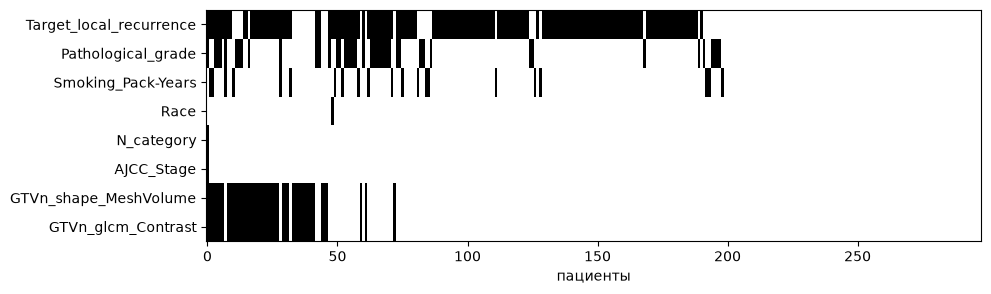

In [20]:
cols = ["Target_local_recurrence", "Pathological_grade", "Smoking_Pack-Years", "Race",
        "N_category", "AJCC_Stage", "GTVn_shape_MeshVolume", "GTVn_glcm_Contrast"]

m = df[cols].isna()
row_order = m.sum(axis=1).sort_values(ascending=False).index
m = m.loc[row_order]

plt.figure(figsize=(10, 3))
plt.imshow(m.T.astype(int), aspect="auto", cmap="gray_r", interpolation="nearest")
plt.yticks(range(len(cols)), cols)
plt.xlabel("пациенты")
plt.show()

In [21]:
known_outcome = df["Target_local_recurrence"].notna()
share = df.loc[known_outcome].isna().mean()

share = share.drop(gtvn[1:]).rename({gtvn[0]: "GTVn_* (107 признаков)"})  # признаки GTVn пропущены вместе
share[share > 0].round(3)

Pathological_grade        0.114
Smoking_Pack-Years        0.071
GTVn_* (107 признаков)    0.143
dtype: float64

In [22]:
(share > 0.3).sum()  # правило: исключить переменную, если пропусков больше 30 %

np.int64(0)

## Признаки

In [23]:
constant_columns = []

for col in df.columns:
    if df[col].nunique(dropna=False) == 1:
        constant_columns.append(col)

constant_columns

[]

In [24]:
without_target = df.drop(columns="Target_local_recurrence")  # целевая — копия источника
duplicate_rows = without_target.T.duplicated()
duplicate_columns = without_target.columns[duplicate_rows].tolist()

duplicate_columns

['GTVp_firstorder_TotalEnergy', 'GTVn_firstorder_TotalEnergy']

In [25]:
duplicates = {
    "GTVp_firstorder_TotalEnergy": "GTVp_firstorder_Energy",
    "GTVn_firstorder_TotalEnergy": "GTVn_firstorder_Energy",
}

for col in duplicates:
    print(col, df[col].equals(df[duplicates[col]]))

GTVp_firstorder_TotalEnergy True
GTVn_firstorder_TotalEnergy True


In [26]:
df = df.drop(columns=[
    "Fold",                                        # служебная, часть набора соревнования
    "Local_tumor_recurrence",                      # источник целевой переменной
    "Radiation_treatment_course_duration",         # известна только после окончания ЛТ
    "KM_Overall_survival_censor",                  # статус на последнем наблюдении
    "GTVp_firstorder_TotalEnergy", "GTVn_firstorder_TotalEnergy",  # дубликаты
])
df.shape

(298, 231)

## Избыточность

In [27]:
clinical_quant = ["Age_at_diagnosis", "Smoking_Pack-Years", "Total_prescribed_Radiation_treatment_dose",
                  "Dose_per_fraction", "#_Radiation_treatment_fractions"]
first = ["GTVp_shape_MeshVolume", "GTVp_shape_Sphericity", "GTVn_n_nodes",
         "GTVn_shape_MeshVolume", "GTVn_shape_Sphericity"]

gtvp_rest = [col for col in gtvp if col in df.columns and col not in first]
gtvn_rest = [col for col in gtvn if col in df.columns and col not in first]

# порядок предпочтения: клинические, GTVp, число узлов, GTVn; внутри маски — объём, сферичность, остальные
quant = clinical_quant + first[:2] + gtvp_rest + first[2:] + gtvn_rest
corr = df[quant].corr(method="spearman")  # ранговая: распределения скошены, есть выбросы плотности
len(quant)

218

In [28]:
corr.loc["GTVp_shape_MeshVolume", "GTVp_firstorder_Energy"]

np.float64(0.898120165992941)

In [29]:
threshold = 0.7
kept = []
replaced_by = {}

for col in quant:
    keep_column = True
    strongest_column = None
    strongest_correlation = 0

    for kept_col in kept:
        correlation = abs(corr.loc[col, kept_col])

        if correlation > strongest_correlation:
            strongest_correlation = correlation
            strongest_column = kept_col

        if correlation > threshold:
            keep_column = False

    if keep_column:
        kept.append(col)
    else:
        replaced_by[col] = strongest_column

len(kept), len(replaced_by)

(41, 177)

In [30]:
replaced_by.update(duplicates)  # дубликат засчитывается тому же признаку, что и его пара


def final(col):
    while col in replaced_by:
        col = replaced_by[col]
    return col


replaces = pd.Series({col: final(col) for col in replaced_by}).value_counts()
pd.Series(kept, index=kept).map(replaces).fillna(0).astype(int)

Age_at_diagnosis                                   0
Smoking_Pack-Years                                 0
Total_prescribed_Radiation_treatment_dose          0
Dose_per_fraction                                  1
GTVp_shape_MeshVolume                             23
GTVp_shape_Sphericity                              0
GTVp_shape_Elongation                              0
GTVp_shape_Flatness                                0
GTVp_firstorder_10Percentile                       1
GTVp_firstorder_90Percentile                       2
GTVp_firstorder_Entropy                           26
GTVp_firstorder_Kurtosis                           3
GTVp_firstorder_Maximum                            0
GTVp_firstorder_Minimum                           25
GTVp_glcm_Correlation                              4
GTVp_glcm_InverseVariance                          0
GTVp_gldm_DependenceNonUniformityNormalized        5
GTVp_glszm_SizeZoneNonUniformityNormalized         1
GTVp_ngtdm_Busyness                           

In [31]:
corr_kept = corr.loc[kept, kept].abs()
off_diagonal = corr_kept.where(~np.eye(len(kept), dtype=bool))

off_diagonal.max().max()

np.float64(0.6975165653700403)

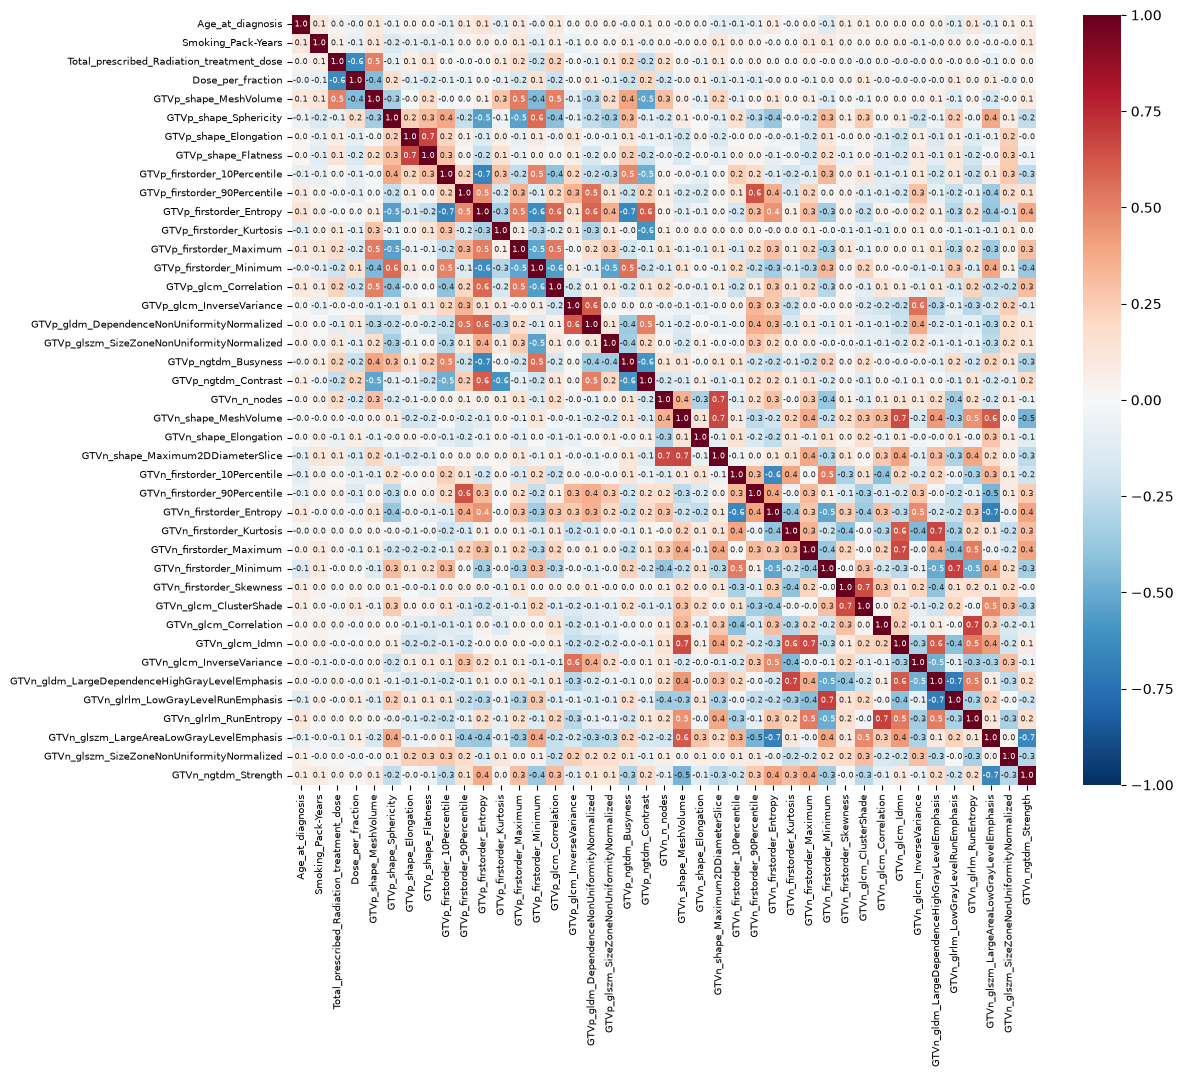

In [32]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr.loc[kept, kept], cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".1f",
            annot_kws={"size": 6}, xticklabels=True, yticklabels=True)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()

## Аналитическая таблица

In [33]:
categorical_features = ["Gender", "Race", "Tumor_side", "Tumor_subsite", "T_category", "N_category",
                        "AJCC_Stage", "Pathological_grade", "Smoking_status_at_diagnosis",
                        "Induction_Chemotherapy", "Concurrent_chemotherapy"]
features = categorical_features + kept
columns_for_analysis = ["Patient_ID", "Target_local_recurrence"] + features

analytic = df.loc[known_outcome, columns_for_analysis].copy()  # без неопределённого исхода
analytic["Target_local_recurrence"] = analytic["Target_local_recurrence"].astype(int)
analytic.to_csv("analytic_table.csv", index=False)

print("пациентов:", len(analytic), " признаков:", len(features))
analytic.head()

пациентов: 140  признаков: 52


,Patient_ID,Target_local_recurrence,Gender,Race,Tumor_side,Tumor_subsite,T_category,N_category,AJCC_Stage,Pathological_grade,...,GTVn_glcm_ClusterShade,GTVn_glcm_Correlation,GTVn_glcm_Idmn,GTVn_glcm_InverseVariance,GTVn_gldm_LargeDependenceHighGrayLevelEmphasis,GTVn_glrlm_LowGrayLevelRunEmphasis,GTVn_glrlm_RunEntropy,GTVn_glszm_LargeAreaLowGrayLevelEmphasis,GTVn_glszm_SizeZoneNonUniformityNormalized,GTVn_ngtdm_Strength
0,1,0,Male,White,L,Tonsil,2,0,II,III,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,Female,White,R,BOT,3,0,III,II,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,0,Female,White,R,BOT,2,2b,IV,III,...,-0.466997,0.544553,0.990002,0.477055,6000.804684,0.036130,3.805138,6729.366148,0.351561,0.017681
3,5,0,Female,White,L,Tonsil,2,2b,IV,II,...,-16.802560,0.598224,0.993376,0.421145,20059.800449,0.012179,4.068082,981.963853,0.312354,0.084864
4,6,0,Male,White,R,BOT,1,1,III,III,...,-5.182591,0.508073,0.992415,0.408073,13935.171038,0.020870,4.017462,908.714088,0.351194,0.099653


In [34]:
analytic["Target_local_recurrence"].value_counts()

Target_local_recurrence
0    128
1     12
Name: count, dtype: int64

In [35]:
na_analytic = analytic.isna().sum()
na_analytic[na_analytic > 0]

Pathological_grade                                16
Smoking_Pack-Years                                10
GTVn_shape_MeshVolume                             20
GTVn_shape_Elongation                             20
GTVn_shape_Maximum2DDiameterSlice                 20
GTVn_firstorder_10Percentile                      20
GTVn_firstorder_90Percentile                      20
GTVn_firstorder_Entropy                           20
GTVn_firstorder_Kurtosis                          20
GTVn_firstorder_Maximum                           20
GTVn_firstorder_Minimum                           20
GTVn_firstorder_Skewness                          20
GTVn_glcm_ClusterShade                            20
GTVn_glcm_Correlation                             20
GTVn_glcm_Idmn                                    20
GTVn_glcm_InverseVariance                         20
GTVn_gldm_LargeDependenceHighGrayLevelEmphasis    20
GTVn_glrlm_LowGrayLevelRunEmphasis                20
GTVn_glrlm_RunEntropy                         